# Example 3: SISO Plant and PID Regulator

This example demonstrates the construction and simulation of a closed-loop control system comprising a toy SISO plant and a PID regulator.
A plant model is defined, a PID controller is configured, and the closed-loop system response to a step-wise reference trajectory is simulated.

## Imports

The required packages are: `Akson` for the core functionality, `torch` for defining state-space system matrices, and `matplotlib` for plotting.

In [1]:
import akson
import torch
import matplotlib.pyplot as plt

## Defining the System Dynamics

An artificial toy plant is used for this example. The LTI state-space system matrices are defined as `torch` tensors:

In [2]:
A = torch.tensor([
    [-0.03333, 0.06667],
    [-0.08, -0.4]
], dtype=torch.float64)
B = torch.tensor([
    [0.],
    [0.2]
], dtype=torch.float64)
C = torch.tensor([[1., 0.]], dtype=torch.float64)
D = torch.tensor([[0.]], dtype=torch.float64)

State-space dynamics are constructed from these matrices using the `from_linear` static method:

In [3]:
system_dynamics = akson.StateSpaceDynamics.from_linear(A, B, C, D)

## Time constant

A single time constant is chosen and shared between the PID regulator and the simulation step. This is required for temporal consistency across the regulator and the plant model:

In [4]:
dt = 5.

## PID Regulator Setup

The MIMO PID regulator is configured with one input-output SISO PID channel. The proportional gain, integral time, and derivative time
are set to $K=4.5$, $T_i=25$, and $T_d=1.2$, respectively. The initial control output `u0` is zero, and the discretisation time step `t` is set
to the previously defined `dt`:

In [5]:
pid_config = akson.PIDRegulatorConfiguration(
    n_inputs=1, n_outputs=1,
    channels=[akson.PIDChannel(input_idx=0, output_idx=0, K=4.5, Ti=25., Td=1.2)],
    u0 = torch.zeros((1,), dtype=torch.float64),
    t=dt
)
pid_state = akson.PIDRegulatorState.initial_state_for(pid_config)

## Closed Loop System Setup

The closed-loop system combines the plant dynamics, the PID regulator configuration, and the respective initial states.
The plant is initialised with a zero state vector of dimension two, corresponding to the two state variables of the system. The PID regulator is initialised with `pid_state`:

In [6]:
pid_closed_system = akson.PIDRegulatorClosedSystem(
    system_dynamics, initial_state=torch.zeros((2,), dtype=torch.float64),
    config=pid_config, state=pid_state
)

## Simulation of the Closed Loop System with Plant and Regulator

The simulation is run over a duration of $200$ time units. A piecewise-constant reference trajectory is defined, consisting of an initial setpoint of $0$ for the first $10$ steps followed by a setpoint of $3$ for the remaining $30$ steps. A substep count of $10$ is used to improve output resolution:

In [7]:
simulation_length = 200
setpoints = torch.tensor([[0.]]*10 +  [[3.]]*30)

t_history, y_history, u_history = pid_closed_system.simulate(
    setpoints=setpoints,
    duration=simulation_length,
    num_substeps=10,  # Fine resolution
)

/home/antoni/Documents/PRACA/akson/src/akson/pid_regulator.py:304: RuntimeWarning: RKF45: 20 consecutive rejected steps at x=5.000e1, step=1.642e-1; problem may be stiff
  t_sub, x_sub = solver.solve(traced_ode_fn, t_span, y0)


The system output is plotted alongside the reference trajectory below:

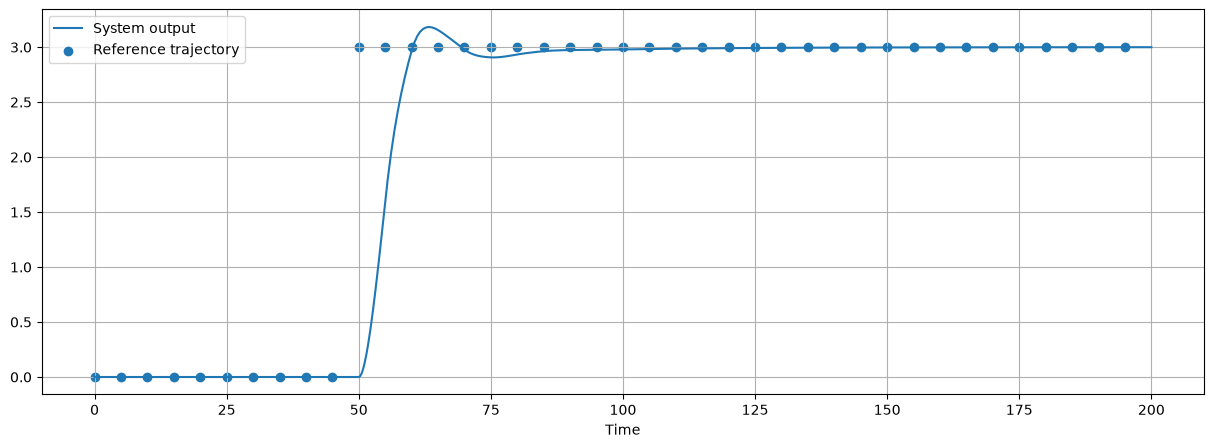

In [8]:
plt.figure(figsize=(15, 5))
plt.plot(t_history, y_history[:, 0])
plt.scatter(torch.arange(setpoints.shape[0])*dt, setpoints[:, 0])
plt.legend(('System output', 'Reference trajectory'))
plt.grid()
plt.xlabel("Time")
plt.show()

The control signal generated by the PID regulator is plotted below:

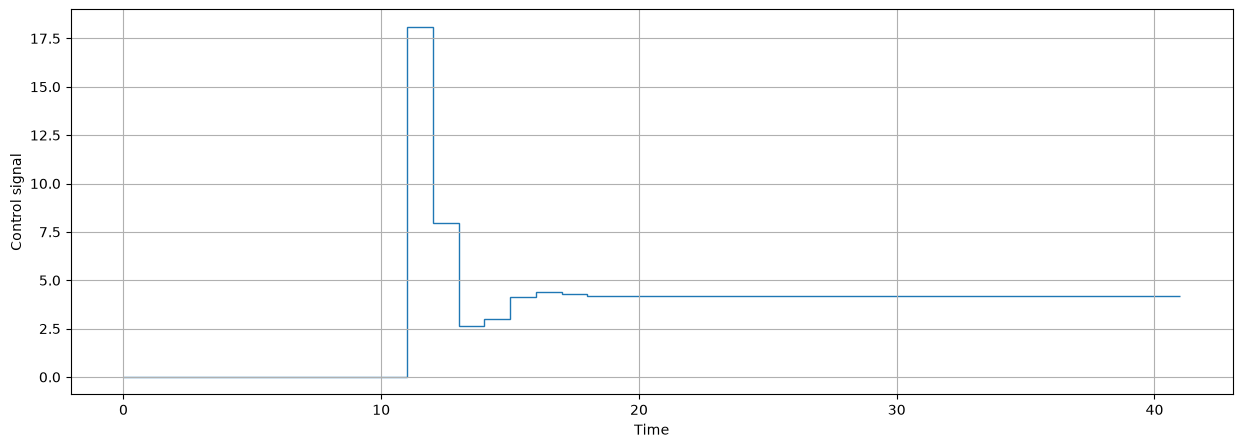

In [9]:
plt.figure(figsize=(15,5))
plt.stairs(u_history[:, 0], range(u_history.shape[0]+1), baseline=None)
plt.grid()
plt.xlabel("Time")
plt.ylabel("Control signal")
plt.show()